### Importing necessary packages and files

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import paretoset
import periodictable
from pymatgen.core import Structure
import ast
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor

In [ ]:
# Importing train and test data
pdata = pd.read_excel("MATSCI_176_Project_Datas.xlsx")
test_data = pd.read_csv("mp_battery_test_data.csv")
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,...,energy_vol,stability_charge,stability_discharge,electrode_density,material_density,battery_workingion_cost_per_kWh,structure,formation_energy_per_atom,band_gap,energy_density
0,Li0-3Ag,Li,['Ag'],1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,...,417.933696,0.003609,0.000000,3.176794,2.592432,108.0,"{'@module': 'pymatgen.core.structure', '@class...",0.333634,0,417.933696
1,Li0-3Sb,Li,['Sb'],1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,...,1920.448911,0.328351,0.000000,3.352100,3.378028,108.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.744135,0.7074,1920.448911
2,Li0-1Bi,Li,['Bi'],1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,...,735.871648,0.049545,0.000000,7.440326,2.237712,108.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.034716,0,735.871648
3,Li0-3Ce,Li,['Ce'],1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,...,-576.149771,0.000000,0.333634,2.592432,2.583328,108.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.330999,0,576.149771
4,Li0-3Ca,Li,['Ca'],1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,...,-82.574983,0.000000,0.057445,0.963259,7.527518,108.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.415156,0,82.574983


Extracting Lattice Parameters

In [ ]:
structures = pdata["structure"]
print(structures.shape)
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)
print(structure_test)
print(structure_test.lattice.abc)
print(structure_test.volume)

(5786,)
Full Formula (Li3 Sb1)
Reduced Formula: Li3Sb
abc   :   4.627959   4.627959   4.627959
angles:  60.000007  60.000010  60.000007
pbc   :       True       True       True
Sites (4)
  #  SP       a      b     c    magmom
---  ----  ----  -----  ----  --------
  0  Li    0.5    0.5   0.5          0
  1  Li    0.25   0.25  0.25        -0
  2  Li    0.75   0.75  0.75        -0
  3  Sb    0     -0     0            0
(4.627959209506349, 4.627958733729667, 4.62795882)
70.08959778250679


In [ ]:
# Defining the function to get lattice parameters
def get_abc(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.lattice.abc
    except:
        return np.nan
structure_abc = pdata["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
pdata = pdata.drop(columns=["structure"], axis=1)
pdata = pd.concat([pdata, structure_abc_df], axis=1)

In [ ]:
# Converting all the columns in training data to float values and eliminate any rows with missing values
numeric_cols = [
    "material_density",
    "formation_energy_per_atom",
    "band_gap"
]

for col in numeric_cols:
    pdata[col] = pd.to_numeric(pdata[col], errors="coerce")
pdata = pdata.dropna()
pdata = pdata.reset_index(drop=True)
pdata_norm = pdata.iloc[:, 6:]

#### Defining our scoring function(s) to analyze and their input datasets.
We use the gravimetric energy density (GED) as our predicted output. Hence, gravimetric and volumetric energy densities and corresponding values are removed from the train dataset. Volumetric capacity is also dropped as it was not available in our test data. The battery material costs were initially planned to be a screening factor, but were dropped from this project. It might be used in future iterations after including more features (namely, atomic contributions).

In [ ]:
# Editing the train dataset
energy_grav = pdata_norm["energy_grav"]
cap_grav = pdata_norm["capacity_grav"]
energy_density = pdata_norm["energy_density"]
voltage = pdata_norm['average_voltage']
training_data = pdata_norm.drop(columns=["energy_grav", "energy_density", "electrode_density", "stability_charge", "energy_vol", "capacity_vol"])
training_data["average_voltage"] = np.abs(training_data["average_voltage"]) # absolute voltage of voltage is taken since the sign only indicates the type of electrode
training_data_nocost = training_data.drop(columns=["battery_workingion_cost_per_kWh"])

In [ ]:
def scoring_nocost(e_g):
    e_g = e_g.to_numpy().astype(float)
    score = np.abs(e_g) # absolute value of GED is used as sign indicates type of electrode
    return pd.Series(score)

### Benchmarking the Ridge & ElasticNet Regressional Models
We chose Ridge regression and ElasticNet regression to both identify important features (from the ElasticNet's Lasso component) while zeroing out features which don't affect battery performance (features that don't affect our score.)

In [ ]:
# Calling the no-cost scoring function and defining our fit & training datasets.
battery_score = scoring_nocost(energy_grav)

fit_train, fit_test, score_train, score_test = train_test_split(
    training_data_nocost,
    battery_score,
    test_size=0.1,
    random_state=42
)

# Normalization of the fit and training datasets for testing ridge without cross validation
norm_fit_train = pd.DataFrame(
    StandardScaler().fit_transform(fit_train),
    columns=fit_train.columns
)
norm_fit_test = pd.DataFrame(
    StandardScaler().fit_transform(fit_test),
    columns=fit_test.columns
)

In [ ]:
# Ridge modelling without CV
ridge = linear_model.Ridge(alpha=3.0).fit(fit_train, score_train, sample_weight=None)
score_pred = ridge.score(fit_test, score_test)
print(f"Effective R^2 score: {score_pred:.3f}")

Effective R^2 score: 0.603


In [ ]:
# Printing out the best predicted battery
best = np.where(battery_score == np.max(battery_score))[0][0]
print(pdata.iloc[best])
print("Battery Score:", np.max(battery_score))


battery_formula                       Li0-3ClO
working_ion                                 Li
elements                           ['Cl', 'O']
nelements                                  2.0
formula_charge                             ClO
formula_discharge                       Li3ClO
max_delta_volume                      1.020934
average_voltage                       4.299346
capacity_grav                      1112.473171
capacity_vol                       2236.418805
energy_grav                        4782.906878
energy_vol                         9615.137841
stability_charge                      1.553271
stability_discharge                   0.027568
electrode_density                     2.010313
material_density                      3.455668
battery_workingion_cost_per_kWh          108.0
formation_energy_per_atom            -0.151988
band_gap                                   0.0
energy_density                     9615.137841
a                                     4.677535
b            



## Performing K-folds cross validation on our ridge regressional model.
Choosing k-folds is important to determine if our train-validation split was truely indicative of the full system.

In [ ]:
X = training_data_nocost
y = battery_score
y = y.fillna(0)
y = y.astype(float)

In [ ]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()), # Normalization
    ("ridge", linear_model.Ridge(alpha=3.0))
])

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42) # 10-fold CV

r2_scores = []
MAE = []
MSE = []
bestmaterial_ridge = []
params = []
best_ridge_score = []

for train_idx, test_idx in kf.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)
    params.append(ridge_pipeline.named_steps["ridge"].coef_)

    #Find best material in predicted set
    bestmaterial_ridge.append(X_test.iloc[np.where(y_pred == np.max(y_pred))[0][0]])
    best_ridge_score.append(np.max(y_pred))

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))
bestmaterial_df_ridge = pd.DataFrame(bestmaterial_ridge)

Mean R2: 0.5621540601761627
Mean MSE: 44804.44849372668
Mean MAE: 127.01733771171118


In [ ]:
# Converting the best material features back to the original scale for comparison with the original dataset, since we normalized the training & test data.
# To do so, we took the best material from each fold and compared their features to the original datasets to find the approximated battery  (the battery formula with the smallest minimum difference between predicted best and the rest of the dataset).
for i in range(len(bestmaterial_df_ridge)):
    best_material = bestmaterial_df_ridge.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material - pdata.iloc[j, 6:6+len(best_material)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Li0-1Cr2(PO4)3
Best material in fold 2:
Ca0.25-0.5C
Best material in fold 3:
Li0-0.25Fe2O3F
Best material in fold 4:
Li1-3Ti2(PO4)3
Best material in fold 5:
Mg7-149Cs
Best material in fold 6:
Mg7-149Cr
Best material in fold 7:
Mg0-1Eu6WO12
Best material in fold 8:
Na0-0.5CrO2
Best material in fold 9:
Li0-0.5CrO2
Best material in fold 10:
Mg7-149V


## Performing K-folds cross validation on our ElasticNet Model

In [ ]:
alpha = 3.25 # Hyperparameter was optimized for best test prediction, not train prediction
l1_ratio = 0.5 # 0=ridge-like, 1=lasso-like

enet_pipeline = Pipeline([
    ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
])

score_pred_enet = enet_pipeline.fit(fit_train, score_train).score(fit_test, score_test)
print("ElasticNet test R^2:", score_pred_enet)

ElasticNet test R^2: 0.5366851725714992


In [ ]:
#replace Ridge KFold with Elastic Net KFold

X = training_data_nocost
y = battery_score.fillna(0).astype(float)

# Elastic Net hyperparameters
alpha = 3.25
l1_ratio = 0.5

enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial_elastic = []
best_elastic_score = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    enet_pipeline.fit(X_train, y_train)
    y_pred = enet_pipeline.predict(X_test)
    bestmaterial_elastic.append(X_test.iloc[np.argmax(y_pred)])
    best_elastic_score.append(np.max(y_pred))

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R^2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))

bestmaterial_df_elastic = pd.DataFrame(bestmaterial_elastic)

Mean R^2: 0.3237995484818546
Mean MSE: 69479.7008097721
Mean MAE: 189.14459837633234


In [ ]:
for i in range(len(bestmaterial_elastic)):
    best_material_temp = bestmaterial_df_elastic.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material_temp - pdata.iloc[j, 6:6+len(best_material_temp)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Mg1-149Bi
Best material in fold 2:
Ca0.25-0.5C
Best material in fold 3:
Li0-0.25Fe2O3F
Best material in fold 4:
Li1-3Ti2(PO4)3
Best material in fold 5:
Mg7-149Cs
Best material in fold 6:
Li0-1Mn4(P2O7)3
Best material in fold 7:
Mg0-1Eu6WO12
Best material in fold 8:
Na0-0.5CrO2
Best material in fold 9:
Li0-0.5CrO2
Best material in fold 10:
Li0-1Co(CO3)2


## Defining and training the XGBoost model

In [ ]:
x_model = XGBRegressor(n_estimators=1000, learning_rate=0.05) # Some tests were also done with other parameters including early_stopping_rounds to identify the best n_estimators/learning_rate balance and the given vaues were chosen
x_model.fit(fit_train, score_train, eval_set=[(fit_test, score_test)], verbose=False)

In [ ]:
xg_pred = x_model.predict(fit_test)
print(f"XGBoost R2 Score: {r2_score(score_test, xg_pred)}")
print(f"MAE of XGBoost: {mean_absolute_error(score_test, xg_pred)}")
print(f"MSE of XGBoost: {mean_squared_error(score_test, xg_pred)}")

# Printing highest predicted battery score for xgboost
best_xgboost_score = np.max(xg_pred)
best_xgboost_index = np.argmax(xg_pred)
print("Best XGBoost Predicted Battery Score:", best_xgboost_score)
print("Best XGBoost Predicted Battery Material:", pdata.iloc[best_xgboost_index, 0])

XGBoost R2 Score: 0.9008787443155742
MAE of XGBoost: 10.436018462354395
MSE of XGBoost: 8959.856394899487
Best XGBoost Predicted Battery Score: 4071.6873
Best XGBoost Predicted Battery Material: Ca0-1Mo2O5


## Testing on other DFT-based features from materials project:
Testing to see if our model & scoring function can predict the quality of a battery based on untrained features, which still correlate with gravimetric energy density.
#### Importing and preprocessing test data similar to how we processed training data:

In [ ]:
test_data = test_data.dropna()
test_data = test_data.reset_index(drop=True)

In [ ]:
structures = test_data["structure"]
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)

In [ ]:
structure_abc = test_data["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
test_data = test_data.drop(columns=["structure"], axis=1)
test_data = pd.concat([test_data, structure_abc_df], axis=1)
test_data = test_data.dropna()
test_data = test_data.reset_index(drop=True)

In [ ]:
# Reformatting the test dataset to conform to train data
stability_discharge = test_data["energy_above_hull"]
material_density = test_data["density"]
formation_energy_per_atom = test_data["formation_energy_per_atom"]
band_gap = test_data["band_gap"]
a = test_data["a"]
b = test_data["b"]
c = test_data["c"]
capacity_grav = test_data["capacity_grav"]
energy_grav = test_data["energy_grav"]
formula_pretty = test_data["formula_pretty"]
max_delta_volume = test_data["max_delta_volume"]
voltage = test_data["average_voltage"]
test_data_short = pd.DataFrame({
    "formula_pretty": formula_pretty,
    "max_delta_volume": max_delta_volume,
    "average_voltage": np.abs(voltage),
    "capacity_grav": capacity_grav,
    "stability_discharge": stability_discharge,
    "material_density": material_density,
    "formation_energy_per_atom": formation_energy_per_atom,
    "band_gap": band_gap,
    "a": a,
    "b": b,
    "c": c,
})

In [ ]:
test_data_short.head()

,formula_pretty,max_delta_volume,average_voltage,capacity_grav,stability_discharge,material_density,formation_energy_per_atom,band_gap,a,b,c
0,CsMg3,0.360047,0.175966,781.306652,0.276177,2.203340,0.276177,0.0,3.752604,4.900757,8.434517
1,CsRb3,2.388242,0.019232,206.531251,0.027286,1.600529,0.027286,0.0,7.391966,7.391966,7.391965
2,CsK3,1.907409,0.032541,321.360236,0.018994,1.192071,0.018994,0.0,8.635094,8.635094,8.635094
3,CsY,0.187048,0.465008,362.490310,0.716882,3.833530,0.716882,0.0,3.843415,3.843415,7.510495
4,CsRb3,2.403271,0.043412,206.531251,0.045421,1.590429,0.045421,0.0,9.078593,9.078593,9.078593


In [ ]:
test_data_feature = test_data_short.drop(columns=["formula_pretty"])
test_data_score = np.abs(energy_grav)
norm_test_data = pd.DataFrame(
    StandardScaler().fit_transform(test_data_feature),
    columns=test_data_feature.columns
)

### Using our testing data to predict GED using XGBoost, Ridge, and ElasticNet
Also printing out the $R^2$ score for each model

In [ ]:
xg_pred = x_model.predict(test_data_feature)
print(f"XGBoost R2 Score: {r2_score(test_data_score, xg_pred)}")
xb_f_weight = x_model.feature_importances_
print(f"MAE of XGBoost: {mean_absolute_error(test_data_score, xg_pred)}")
print(f"MSE of XGBoost: {mean_squared_error(test_data_score, xg_pred)}")

XGBoost R2 Score: 0.7547105151293501
MAE of XGBoost: 46.84118094665686
MSE of XGBoost: 53366.591513655985


In [ ]:
test_pred_ridge = ridge_pipeline.predict(test_data_feature)
print(f"Ridge R2 Score: {r2_score(np.abs(test_data_score), test_pred_ridge)}")
ridge_f_weight = ridge_pipeline.named_steps["ridge"].coef_
print(f"MAE of Ridge: {mean_absolute_error(test_data_score, test_pred_ridge)}")
print(f"MSE of Ridge: {mean_squared_error(test_data_score, test_pred_ridge)}")


Ridge R2 Score: -0.8574107614184205
MAE of Ridge: 347.4297905152375
MSE of Ridge: 404108.97120175004


In [ ]:
test_pred_enet = enet_pipeline.predict(test_data_feature)
print(f"Elastic Net R2 Score: {r2_score(np.abs(test_data_score), test_pred_enet)}")
enet_f_weight = enet_pipeline.named_steps["enet"].coef_
print(f"MAE of Elastic Net: {mean_absolute_error(test_data_score, test_pred_enet)}")
print(f"MSE of Elastic Net: {mean_squared_error(test_data_score, test_pred_enet)}")

Elastic Net R2 Score: 0.10457235694708689
MAE of Elastic Net: 288.62306421748605
MSE of Elastic Net: 194814.3895448263


### Comparing the GED predictions from Ridge, ElasticNet, and XGBoost relative to the true value.

In [ ]:
random_mats = energy_grav.sample(n=10, random_state=42).values.flatten()
random_index = [energy_grav[energy_grav == val].index[0] for val in random_mats]

Text(0.5, 1.0, 'Comparing Predicted Scores for Randomly Selected Materials from our three models to the actual GED value')

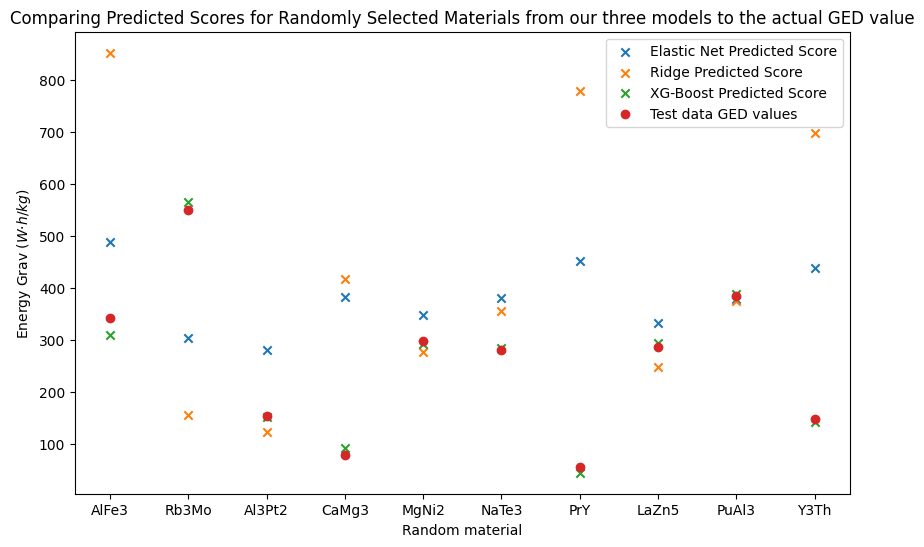

In [ ]:
random_materials = test_data_short.loc[random_index, "formula_pretty"].values
plt.figure(figsize=(10, 6))
plt.scatter(random_materials, test_pred_enet[random_index], marker='x', label='Elastic Net Predicted Score')
plt.scatter(random_materials, test_pred_ridge[random_index], marker='x', label='Ridge Predicted Score')
plt.scatter(random_materials, xg_pred[random_index], marker='x', label='XG-Boost Predicted Score')
plt.scatter(random_materials, np.abs(random_mats), marker='o', label='Test data GED values') # plotting the magnitude of GED as that is what our model predicts
plt.xlabel('Random material')
plt.ylabel(r'Energy Grav $(W⋅h/kg)$')
plt.legend()
plt.title('Comparing Predicted Scores for Randomly Selected Materials from our three models to the actual GED value')

In [ ]:
# Printing residuals for the randomly selected materials
residuals_enet = test_pred_enet[random_index] - random_mats
residuals_ridge = test_pred_ridge[random_index] - random_mats
residuals_xgboost = xg_pred[random_index] - random_mats
print("Elastic Net Residuals:", residuals_enet)
print("Ridge Residuals:", residuals_ridge)
print("XGBoost Residuals:", residuals_xgboost)

Elastic Net Residuals: [ 830.12287864 -245.35974131  434.84557728  460.65406963  645.55368188
   99.76693389  397.09873363   46.1987001    -5.63591969  290.04238759]
Ridge Residuals: [1194.50475661 -393.95013643  278.01343952  494.7516422   573.23211278
   74.95032706  723.62063669  -39.86321417   -9.49412023  549.24031421]
XGBoost Residuals: [652.1333501   15.91459099 306.26712279 170.62948398 589.58902945
   3.42471627 -10.21339979   7.6365922    3.06998743  -5.67885513]


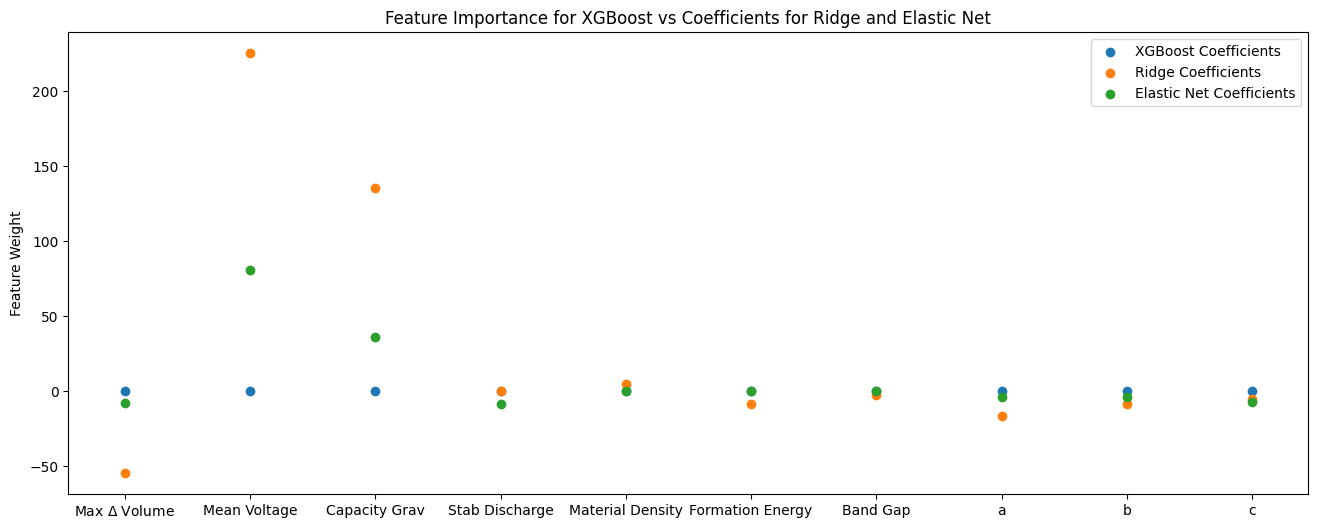

In [ ]:
# Plotting the feature importance for the XGBoost model against feature weights for ridge and elastic net with feature names for comparison
feature_names = [r"Max $\Delta$ Volume", r"Mean Voltage", r"Capacity Grav", r"Stab Discharge", r"Material Density", r"Formation Energy", r"Band Gap", r"a", r"b", r"c"]
plt.figure(figsize=(16, 6))
plt.scatter(feature_names, xb_f_weight, alpha=1, label='XGBoost Coefficients')
plt.scatter(feature_names, ridge_f_weight, alpha=1, label='Ridge Coefficients')
plt.scatter(feature_names, enet_f_weight, alpha=1, label='Elastic Net Coefficients')
plt.ylabel('Feature Weight')
plt.title('Feature Importance for XGBoost vs Coefficients for Ridge and Elastic Net')
plt.legend()